In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
products = ['Laptop', 'Phone', 'Tablet', 'Watch', 'Earbuds']
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

sales_2d = np.array([
    [12000, 15000, 13000, 18000],
    [20000, 22000, 19000, 25000],
    [8000,   9500,  8700, 11000],
    [5000,   6000,  5500,  7000],
    [3000,   4000,  3500,  4500]
])

print("Total sales per product:")
total = sales_2d.sum(axis=1)
[print(f'{p}: {t}') for p, t in zip(products, total)]

print("\nAverage sales per quarter:")
avg = sales_2d.mean(axis=0).round(2)
[print(f'{q}: {a}') for q, a in zip(quarters, avg)]

print(f"\nBest selling product: {products[np.argmax(total)]} ({total.max()} units)")
print(f"Worst selling product: {products[np.argmin(total)]} ({total.min()} units)")

print("\nQ4 vs Q1 difference:")
diff = sales_2d[:, 3] - sales_2d[:, 0]
[print(f'{p}: +{d}' if d >= 0 else f'{p}: {d}') for p, d in zip(products, diff)]

print("\nProducts where all quarters > 5000:")
for i, p in enumerate(products):
    if np.all(sales_2d[i] > 5000):
        print(f'  {p}')

flat = sales_2d.flatten()
print(f"\nTotal overall units: {flat.sum()}")
print(f"Max: {flat.max()}  Min: {flat.min()}")


Total sales per product:
Laptop: 58000
Phone: 86000
Tablet: 37200
Watch: 23500
Earbuds: 15000

Average sales per quarter:
Q1: 9600.0
Q2: 11300.0
Q3: 9940.0
Q4: 13100.0

Best selling product: Phone (86000 units)
Worst selling product: Earbuds (15000 units)

Q4 vs Q1 difference:
Laptop: +6000
Phone: +5000
Tablet: +3000
Watch: +2000
Earbuds: +1500

Products where all quarters > 5000:
  Laptop
  Phone
  Tablet

Total overall units: 219700
Max: 25000  Min: 3000


In [7]:
data = {
    'Name':       ['Amit', 'Sara', 'Ravi', 'Neha', 'Suresh', 'Priya', 'Kiran'],
    'Department': ['North', 'South', 'North', 'East', 'South', 'East', 'North'],
    'Product':    ['Laptop', 'Phone', 'Tablet', 'Laptop', 'Earbuds', 'Watch', 'Phone'],
    'Units_Sold': [45, 60, 30, 55, 80, 40, 70],
    'Price':      [50000, 20000, 15000, 50000, 3000, 8000, 20000]
}

df = pd.DataFrame(data)
df['Revenue'] = df['Units_Sold'] * df['Price']

print("\n--- Full DataFrame ---")
print(df)

print("\n--- Top 5 rows ---")
print(df.head())

print("\n--- Statistics ---")
print(df.describe())

# filter
above_50 = df[df['Units_Sold'] > 50]
print("\nEmployees with units sold > 50:")
print(above_50[['Name', 'Units_Sold', 'Revenue']])

# sort
sorted_df = df.sort_values('Revenue', ascending=False)
print("\nSorted by Revenue:")
print(sorted_df[['Name', 'Product', 'Revenue']])

# apply - grade
def assign_grade(units):
    if units >= 70:   return 'A'
    elif units >= 50: return 'B'
    elif units >= 30: return 'C'
    else:             return 'D'

df['Grade'] = df['Units_Sold'].apply(assign_grade)
print("\nWith Grades:")
print(df[['Name', 'Units_Sold', 'Grade']])

# groupby
dept_revenue = df.groupby('Department')['Revenue'].sum()
print("\nRevenue per Department:")
print(dept_revenue)

dept_count = df.groupby('Department')['Name'].count()
print("\nEmployee count per Department:")
print(dept_count)

# agg
result = df.groupby('Department').agg({'Revenue': 'sum', 'Units_Sold': 'mean', 'Name': 'count'})
result.rename(columns={'Revenue': 'Total Revenue', 'Units_Sold': 'Avg Units', 'Name': 'Emp Count'}, inplace=True)
print("\nDepartment Summary:")
print(result)

# highest revenue
top = df.loc[df['Revenue'].idxmax()]
print(f"\nHighest revenue: {top['Name']} - Rs.{top['Revenue']}")

# unique
print("\nUnique Products:", df['Product'].unique())

# missing values
print("\nMissing values:")
print(df.isnull().sum())

# merge
targets = pd.DataFrame({
    'Name':   ['Amit', 'Sara', 'Ravi', 'Neha', 'Suresh', 'Priya', 'Kiran'],
    'Target': [2000000, 1500000, 500000, 2500000, 300000, 400000, 1500000]
})
merged = pd.merge(df, targets, on='Name')
merged['Achieved'] = merged['Revenue'] >= merged['Target']
print("\nTarget vs Achievement:")
print(merged[['Name', 'Revenue', 'Target', 'Achieved']])


--- Full DataFrame ---
     Name Department  Product  Units_Sold  Price  Revenue
0    Amit      North   Laptop          45  50000  2250000
1    Sara      South    Phone          60  20000  1200000
2    Ravi      North   Tablet          30  15000   450000
3    Neha       East   Laptop          55  50000  2750000
4  Suresh      South  Earbuds          80   3000   240000
5   Priya       East    Watch          40   8000   320000
6   Kiran      North    Phone          70  20000  1400000

--- Top 5 rows ---
     Name Department  Product  Units_Sold  Price  Revenue
0    Amit      North   Laptop          45  50000  2250000
1    Sara      South    Phone          60  20000  1200000
2    Ravi      North   Tablet          30  15000   450000
3    Neha       East   Laptop          55  50000  2750000
4  Suresh      South  Earbuds          80   3000   240000

--- Statistics ---
       Units_Sold         Price       Revenue
count    7.000000      7.000000  7.000000e+00
mean    54.285714  23714.285714 

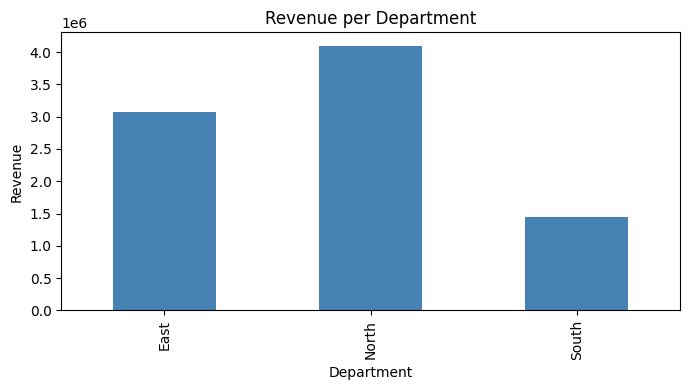

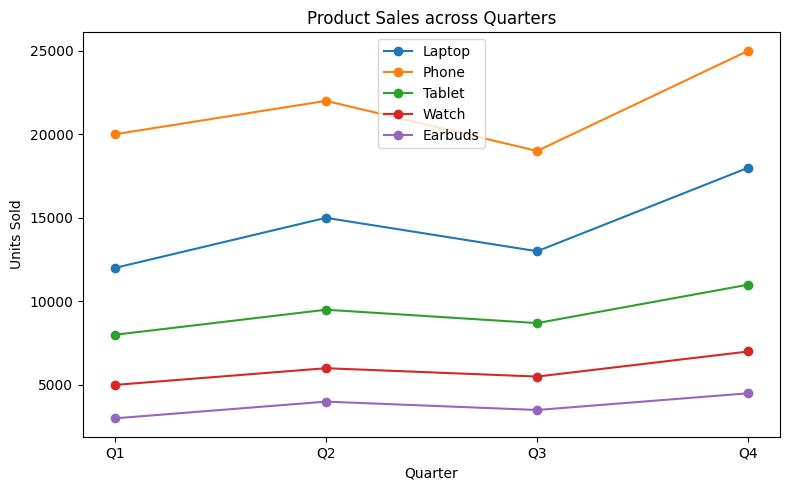

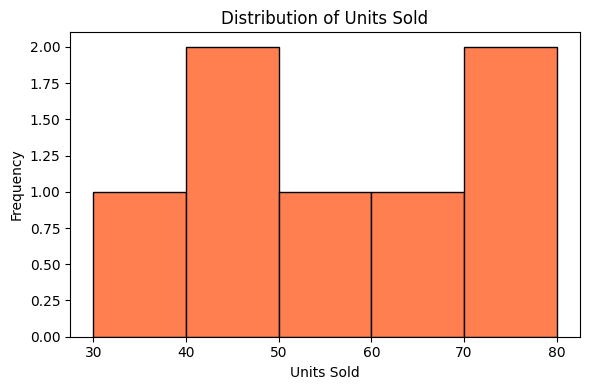

In [8]:
# bar chart
plt.figure(figsize=(7, 4))
dept_revenue.plot(kind='bar', color='steelblue')
plt.title("Revenue per Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# line chart
plt.figure(figsize=(8, 5))
for i, p in enumerate(products):
    plt.plot(quarters, sales_2d[i], marker='o', label=p)
plt.title("Product Sales across Quarters")
plt.xlabel("Quarter")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

# histogram
plt.figure(figsize=(6, 4))
plt.hist(df['Units_Sold'], bins=5, color='coral', edgecolor='black')
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()